# ANALYSE DES VENTES D'UNE LIBRAIRIE

## 1. Chargement et exploration des fichiers

### 1.1 Importation des librairies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import spearmanr
from scipy.stats import kruskal
from scipy.stats import f_oneway

### 1.2 Fichier customers

In [3]:
#chargement du fichier
customers = pd.read_csv(r"C:\Users\agnes\OneDrive/Documents/Formation/Projet 9 Analyser les ventes d'une librairie avec Python/customers.csv",sep=";")
customers.head()

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [4]:
#infos sur le fichier
print(customers.info())
print("\nNombre de valeurs uniques pour chaque colonne :")
for col in customers.columns.values:
    print(f"{col} : {customers[col].unique().shape[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB
None

Nombre de valeurs uniques pour chaque colonne :
client_id : 8621
sex : 2
birth : 76


In [5]:
#vérification doublons dans les id
print(f"Il y a {customers.duplicated(keep=False).sum()} doublon(s) dans le fichier customers.")

Il y a 0 doublon(s) dans le fichier customers.


### 1.3 Fichier products

In [6]:
#chargement du fichier
products = pd.read_csv(r"C:\Users\agnes\OneDrive/Documents/Formation/Projet 9 Analyser les ventes d'une librairie avec Python/products.csv",sep=";")
products.head()

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [7]:
#infos sur le fichier
print(products.info())
print("\nNombre de valeurs uniques pour chaque colonne :")
for col in products.columns.values:
    print(f"{col} : {products[col].unique().shape[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB
None

Nombre de valeurs uniques pour chaque colonne :
id_prod : 3286
price : 1454
categ : 3


In [8]:
#vérification doublons dans les id
print(f"Il y a {products.duplicated(keep=False).sum()} doublon(s) dans le fichier products.")

Il y a 0 doublon(s) dans le fichier products.


### 1.4 Fichier Transactions

In [9]:
#Chargement du fichier
transactions = pd.read_csv(r"C:\Users\agnes\OneDrive/Documents/Formation/Projet 9 Analyser les ventes d'une librairie avec Python/Transactions.csv",sep=";")
transactions.head()

C:\Users\agnes\AppData\Local\Temp\ipykernel_37808\425824849.py:2: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv(r"C:\Users\agnes\OneDrive/Documents/Formation/Projet 9 Analyser les ventes d'une librairie avec Python/Transactions.csv",sep=";")


,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


In [10]:
#infos sur le fichier
print(transactions.info())
print("\nNombre de valeurs uniques pour chaque colonne :")
for col in transactions.columns.values:
    print(f"{col} : {transactions[col].unique().shape[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB
None

Nombre de valeurs uniques pour chaque colonne :
id_prod : 3266
date : 687420
session_id : 345506
client_id : 8601


In [11]:
#suppression des lignes vides (qui provoquaient le warning au chargement car mélange de types de données dans les colonnes)
transactions = transactions.loc[~(transactions['id_prod'].isna()&transactions['date'].isna()&transactions['session_id'].isna()&transactions['client_id'].isna()),:]

In [12]:
#changement de type en date pour la colonne "date"
transactions['date'] = pd.to_datetime(transactions['date'], errors = "coerce")

In [13]:
#nouvelles infos sur le fichier
transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     687534 non-null  object        
 1   date        687534 non-null  datetime64[ns]
 2   session_id  687534 non-null  object        
 3   client_id   687534 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 26.2+ MB


In [14]:
#vérification doublons dans le fichier
print(f"Il y a {transactions.duplicated(keep=False).sum()} doublon(s) dans le fichier transactions.")

Il y a 0 doublon(s) dans le fichier transactions.


### 1.5 Fusion des fichiers

In [15]:
#Fusion Transactions et products
df_merge = pd.merge(transactions,products,left_on='id_prod',right_on='id_prod',how='left')
df_merge

,id_prod,date,session_id,client_id,price,categ
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0
...,...,...,...,...,...,...
687529,1_508,2023-02-28 23:49:03.148402,s_348444,c_3573,21.92,1
687530,2_37,2023-02-28 23:51:29.318531,s_348445,c_50,48.99,2
687531,1_695,2023-02-28 23:53:18.929676,s_348446,c_488,26.99,1
687532,0_1547,2023-02-28 23:58:00.107815,s_348447,c_4848,8.99,0


In [16]:
#Fusion merge et customers
df_merge = pd.merge(df_merge,customers,left_on='client_id',right_on='client_id',how='left')
df_merge

,id_prod,date,session_id,client_id,price,categ,sex,birth
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956
...,...,...,...,...,...,...,...,...
687529,1_508,2023-02-28 23:49:03.148402,s_348444,c_3573,21.92,1,f,1996
687530,2_37,2023-02-28 23:51:29.318531,s_348445,c_50,48.99,2,f,1994
687531,1_695,2023-02-28 23:53:18.929676,s_348446,c_488,26.99,1,f,1985
687532,0_1547,2023-02-28 23:58:00.107815,s_348447,c_4848,8.99,0,m,1953


## 2. Analyse des indicateurs de ventes

### 2.1 Profil des clients

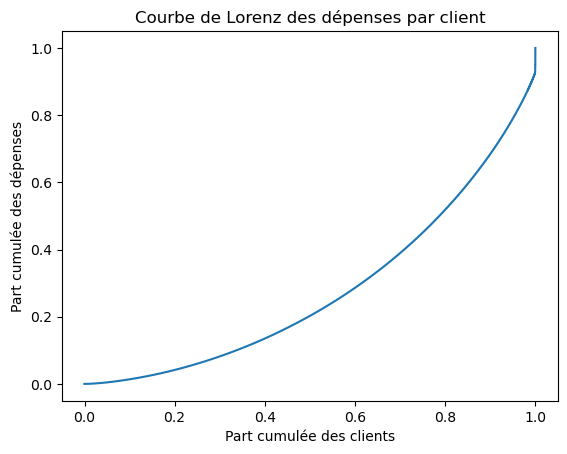

In [17]:
#Courbe de lorenz
dep_par_client = df_merge.groupby('client_id')['price'].sum().reset_index()
dep = dep_par_client['price']
n = len(dep)
lorenz = np.cumsum(np.sort(dep)) / dep.sum()
lorenz = np.append([0],lorenz) 

xaxis = np.linspace(0-1/n,1+1/n,n+1) 
plt.title('Courbe de Lorenz des dépenses par client')
plt.xlabel('Part cumulée des clients')
plt.ylabel('Part cumulée des dépenses')
plt.plot(xaxis,lorenz,drawstyle='steps-post')
plt.show()

In [18]:
#Observation de ce groupe de clients
dep_par_client = dep_par_client.sort_values('price',ascending = False)
dep_par_client['dep_cumul'] = dep_par_client['price'].cumsum()
dep_par_client['%_dep_cumul'] = round(dep_par_client['dep_cumul'] / dep_par_client['price'].sum(),2)
groupe = dep_par_client.loc[dep_par_client['%_dep_cumul'] <= 0.6,['client_id','price']]
print(f'Ci-dessous la liste de ces clients : \n\n {groupe}')

Ci-dessous la liste de ces clients : 

      client_id      price
677     c_1609  326039.89
4388    c_4958  290227.03
6337    c_6714  153918.60
2724    c_3454  114110.57
634     c_1570    5285.82
...        ...        ...
7047    c_7356    1627.36
4427    c_4993    1627.27
6042    c_6449    1626.88
5917    c_6336    1626.71
4106    c_4703    1626.29

[2538 rows x 2 columns]


In [19]:
#Création df sans btob
clients_btob = ['c_1609', 'c_4958', 'c_6714', 'c_3454']
df_merge_btoc = df_merge.loc[~df_merge['client_id'].isin(clients_btob),:]

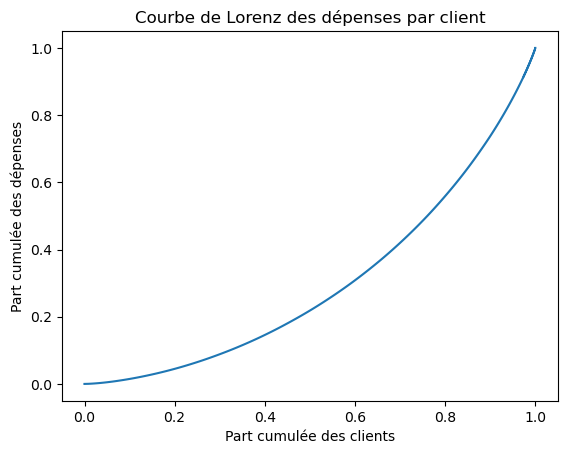

In [20]:
#Courbe de Lorenz clients BtoC
dep_par_client_btoc = df_merge_btoc.groupby('client_id')['price'].sum().reset_index()
dep = dep_par_client_btoc['price']
n = len(dep)
lorenz = np.cumsum(np.sort(dep)) / dep.sum()
lorenz = np.append([0],lorenz) 

xaxis = np.linspace(0-1/n,1+1/n,n+1) 
plt.title('Courbe de Lorenz des dépenses par client')
plt.xlabel('Part cumulée des clients')
plt.ylabel('Part cumulée des dépenses')
plt.plot(xaxis,lorenz,drawstyle='steps-post')
plt.show()

In [21]:
#Identification des clients du groupe VIP
dep_par_client_btoc = dep_par_client_btoc.sort_values('price',ascending = False)
dep_par_client_btoc['dep_cumul'] = dep_par_client_btoc['price'].cumsum()
dep_par_client_btoc['%_dep_cumul'] = round(dep_par_client_btoc['dep_cumul'] / dep_par_client_btoc['price'].sum(),2)
groupe_VIP = dep_par_client_btoc.loc[dep_par_client_btoc['%_dep_cumul'] <= 0.7,['client_id','price']]
print(f'Il y a {groupe_VIP.shape[0]} clients dans le groupe VIP. \n\nCi-dessous la liste de ces clients : \n\n {groupe_VIP}')

Il y a 3555 clients dans le groupe VIP. 

Ci-dessous la liste de ces clients : 

      client_id    price
634     c_1570  5285.82
2512    c_3263  5276.87
1267    c_2140  5260.18
2107    c_2899  5214.05
7002    c_7319  5155.77
...        ...      ...
6135    c_6535  1259.24
2609    c_3350  1259.00
2870    c_3589  1258.91
3105    c_3800  1258.51
1879    c_2692  1258.48

[3555 rows x 2 columns]


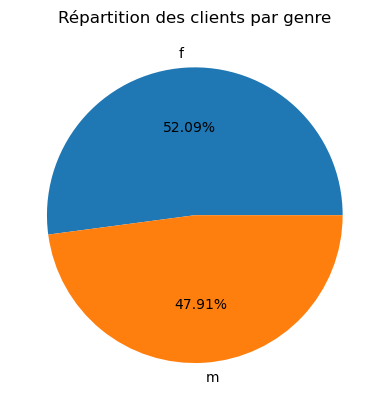

In [22]:
#Répartition par genre
#suppression des clients btoc dans la table customers
customers_btoc = customers.loc[~customers['client_id'].isin(clients_btob),:]

client_par_genre = customers_btoc['sex'].value_counts().reset_index()
plt.pie(x=client_par_genre['count'], labels = client_par_genre['sex'],autopct ='%.2f%%')
plt.title('Répartition des clients par genre')
plt.show()

C:\Users\agnes\AppData\Local\Temp\ipykernel_37808\1724379835.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customers_btoc.loc[:,'age'] = 2022 - customers_btoc['birth']


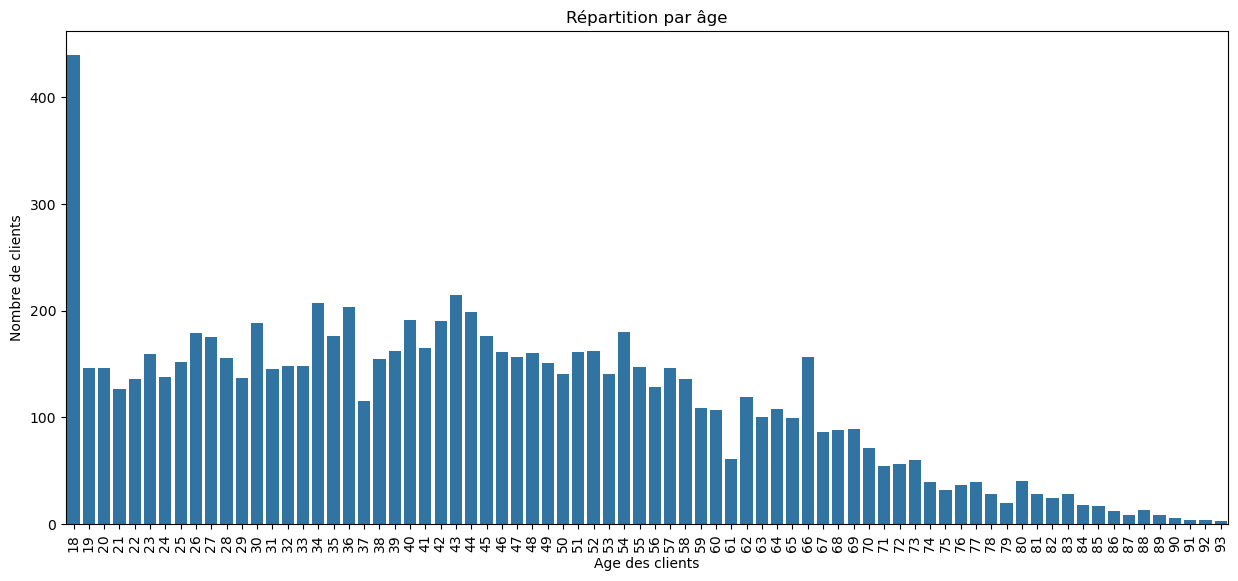

In [23]:
#Visualisation de l'âge des clients
customers_btoc.loc[:,'age'] = 2022 - customers_btoc['birth'] 
plt.figure(figsize=(15,6.4))
plt.xticks(rotation=90)
sns.countplot(x = 'age',data = customers_btoc)
plt.title('Répartition par âge')
plt.xlabel("Age des clients")
plt.ylabel('Nombre de clients')
plt.show()

### 2.2 Evolution dans le temps

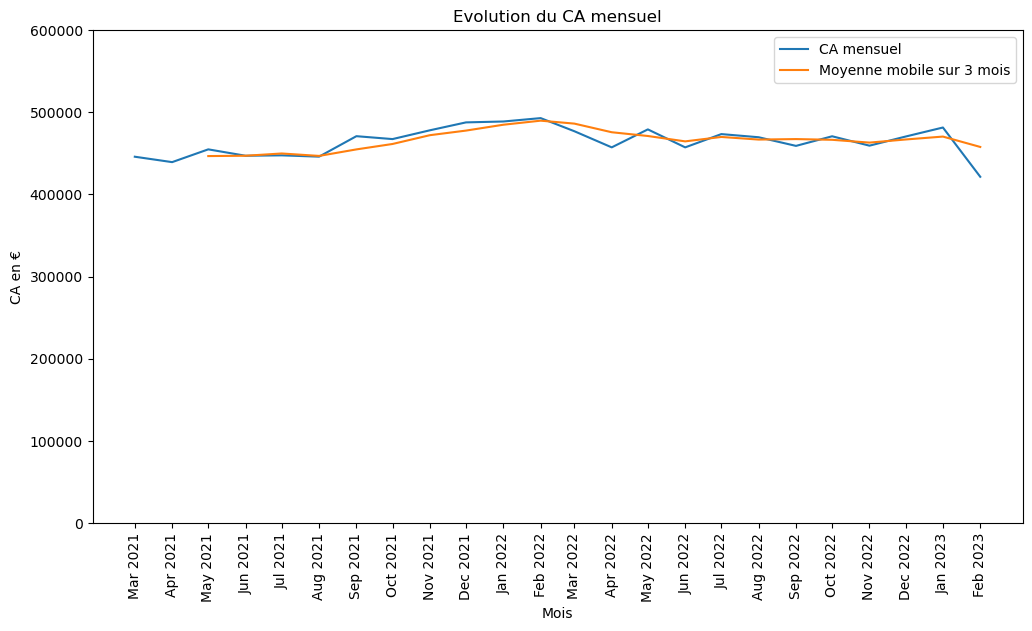

In [24]:
#Evolution du CA mensuel
ca_par_mois = df_merge_btoc.groupby(df_merge_btoc['date'].dt.to_period('M').dt.to_timestamp())['price'].sum().reset_index()
plt.figure(figsize=(12,6.4))
plt.title('Evolution du CA mensuel')
plt.ylim(0,600000)
plt.xlabel("Mois")
plt.ylabel("CA en €")
plt.xticks(ca_par_mois['date'],ca_par_mois['date'].dt.strftime('%b %Y'),rotation=90)
plt.plot(ca_par_mois['date'],ca_par_mois['price'],label='CA mensuel')
plt.plot(ca_par_mois['date'],ca_par_mois['price'].rolling(3).mean(),label='Moyenne mobile sur 3 mois')
plt.legend()
plt.show()

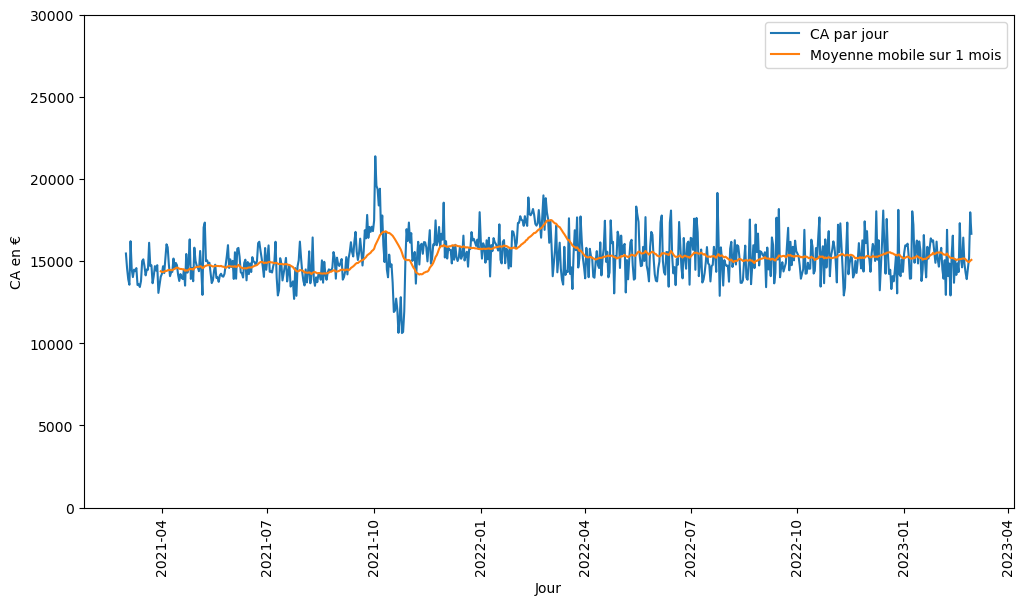

In [25]:
#Evolution du CA par jour
ca_par_jour = df_merge_btoc.groupby(df_merge_btoc['date'].dt.floor('D'))['price'].sum().reset_index()
plt.figure(figsize=(12,6.4))
plt.ylim(0,30000)
plt.xlabel("Jour")
plt.ylabel("CA en €")
plt.xticks(rotation=90)
plt.plot(ca_par_jour['date'],ca_par_jour['price'],label='CA par jour')
plt.plot(ca_par_jour['date'],ca_par_jour['price'].rolling(31).mean(),label='Moyenne mobile sur 1 mois')
plt.legend()
plt.show()

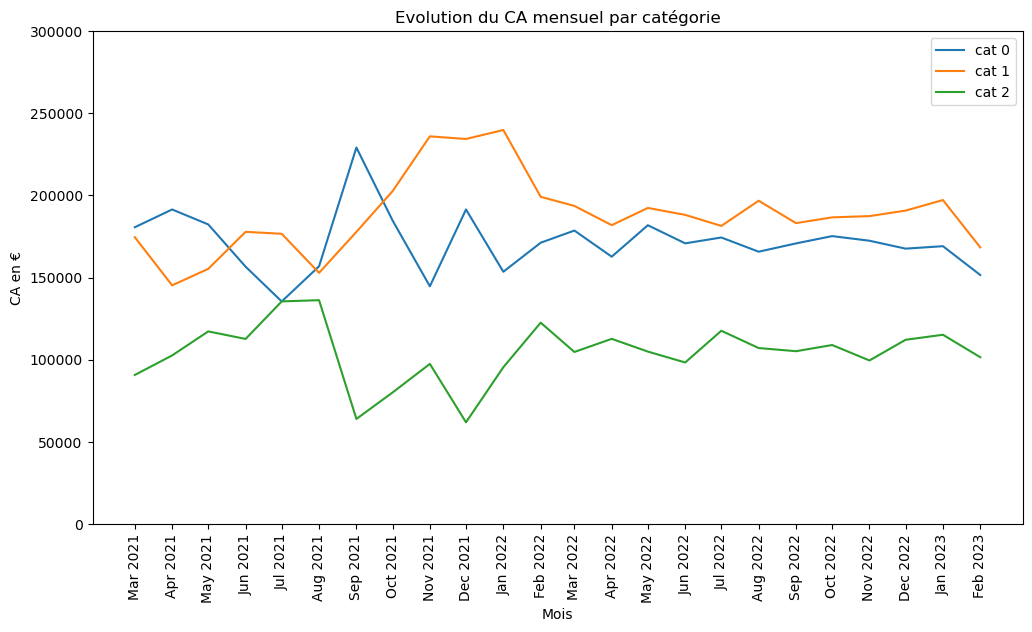

In [26]:
#Evolution du CA mensuel par catégorie
ca_par_mois_par_cat = df_merge_btoc.pivot_table(index=df_merge_btoc['date'].dt.to_period('M').dt.to_timestamp(),columns='categ',values='price',aggfunc ='sum')
dates = ca_par_mois_par_cat.index
plt.figure(figsize=(12,6.4))
plt.title('Evolution du CA mensuel par catégorie')
plt.ylim(0,300000)
plt.xlabel("Mois")
plt.ylabel("CA en €")
plt.xticks(dates,dates.strftime('%b %Y'),rotation=90)
plt.plot(dates,ca_par_mois_par_cat[0],label='cat 0')
plt.plot(dates,ca_par_mois_par_cat[1],label='cat 1')
plt.plot(dates,ca_par_mois_par_cat[2],label='cat 2')
plt.legend()
plt.show()

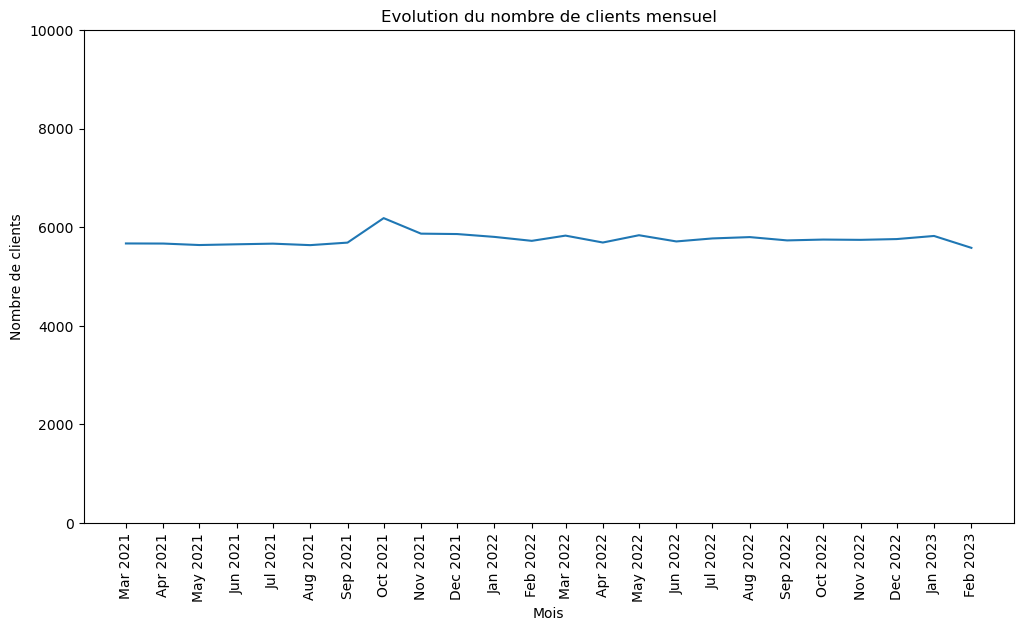

In [27]:
#Evolution du nombre de clients mensuel
clients_par_mois = df_merge_btoc.groupby(df_merge_btoc['date'].dt.to_period('M').dt.to_timestamp())['client_id'].nunique().reset_index()
plt.figure(figsize=(12,6.4))
plt.title('Evolution du nombre de clients mensuel')
plt.ylim(0,10000)
plt.xlabel("Mois")
plt.ylabel("Nombre de clients")
plt.xticks(clients_par_mois['date'],clients_par_mois['date'].dt.strftime('%b %Y'),rotation=90)
plt.plot(clients_par_mois['date'],clients_par_mois['client_id'])
plt.show()

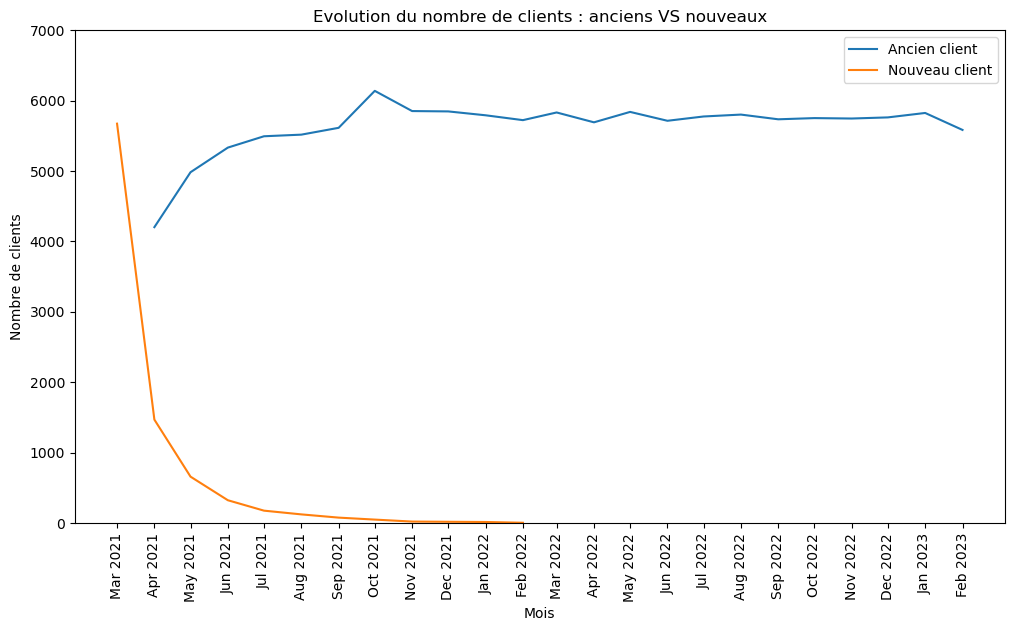

In [28]:
#Evolution du nombre de clients : anciens VS nouveaux
mois_premier_achat = df_merge_btoc.groupby('client_id')['date'].min().reset_index()
mois_premier_achat['date'] = mois_premier_achat['date'].dt.to_period('M').dt.to_timestamp()
df_pour_client = df_merge_btoc[['date','client_id']]
df_pour_client = pd.merge(df_pour_client,mois_premier_achat,left_on='client_id',right_on='client_id',how='left')
df_pour_client = df_pour_client.rename(columns={'date_x' : 'date','date_y': 'mois premier achat'})
df_pour_client['date'] = df_pour_client['date'].dt.to_period('M').dt.to_timestamp()
df_pour_client = df_pour_client.drop_duplicates(keep='first')
df_pour_client['client'] = 'Ancien client'
df_pour_client.loc[df_pour_client['date'] == df_pour_client['mois premier achat'],'client'] = 'Nouveau client'
df_pour_client = df_pour_client.pivot_table(index='date',columns='client',values='client_id',aggfunc ='count')
dates = df_pour_client.index
plt.figure(figsize=(12,6.4))
plt.title('Evolution du nombre de clients : anciens VS nouveaux')
plt.ylim(0,7000)
plt.xlabel("Mois")
plt.ylabel("Nombre de clients")
plt.xticks(dates,dates.strftime('%b %Y'),rotation=90)
plt.plot(dates,df_pour_client['Ancien client'],label='Ancien client')
plt.plot(dates,df_pour_client['Nouveau client'],label='Nouveau client')
plt.legend()
plt.show()

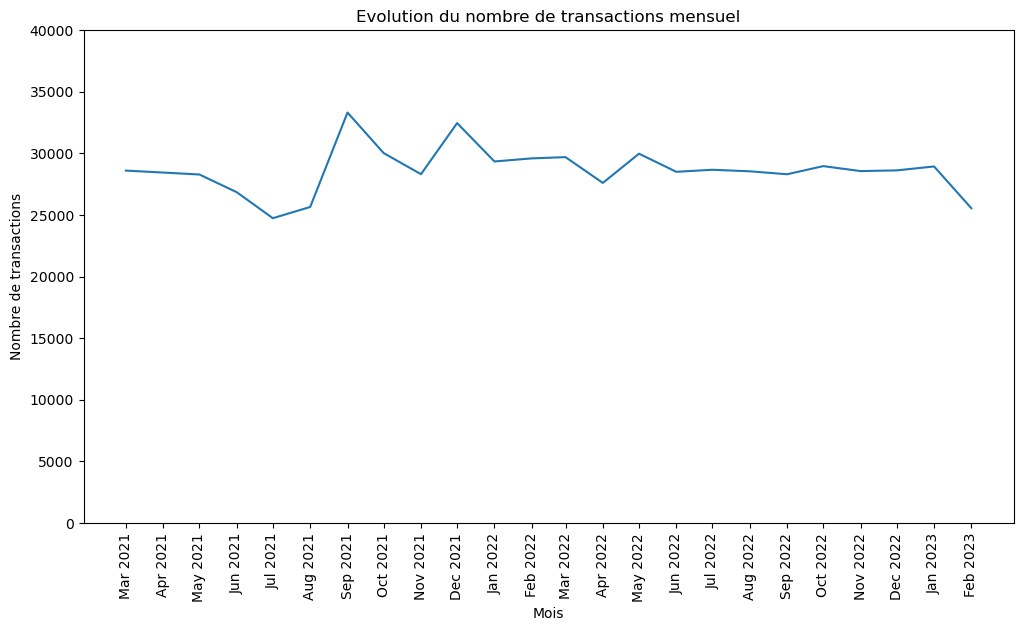

In [29]:
#Evolution du nombre de transactions mensuel
transactions_par_mois = df_merge.groupby(df_merge['date'].dt.to_period('M').dt.to_timestamp())['session_id'].count().reset_index()
plt.figure(figsize=(12,6.4))
plt.title('Evolution du nombre de transactions mensuel')
plt.ylim(0,40000)
plt.xlabel("Mois")
plt.ylabel("Nombre de transactions")
plt.xticks(transactions_par_mois['date'],transactions_par_mois['date'].dt.strftime('%b %Y'),rotation=90)
plt.plot(transactions_par_mois['date'],transactions_par_mois['session_id'])
plt.show()

### 2.3 Zoom sur les références produits

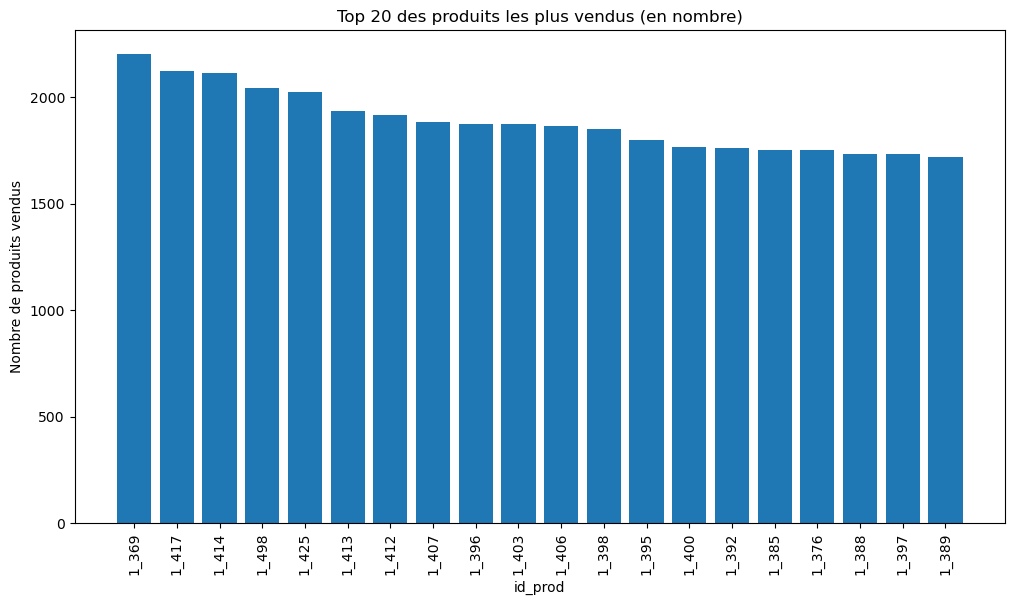

In [30]:
#Produits les plus vendus en quantité
top_produits = df_merge_btoc['id_prod'].value_counts().reset_index().head(20)
plt.figure(figsize=(12,6.4))
plt.xlabel('id_prod')
plt.ylabel('Nombre de produits vendus')
plt.title('Top 20 des produits les plus vendus (en nombre)')
plt.xticks(rotation=90)
plt.bar(height=top_produits['count'],x=top_produits['id_prod'])
plt.show()

In [31]:
top_produits

,id_prod,count
0,1_369,2205
1,1_417,2123
2,1_414,2114
3,1_498,2042
4,1_425,2026
5,1_413,1935
6,1_412,1915
7,1_407,1883
8,1_396,1875
9,1_403,1874


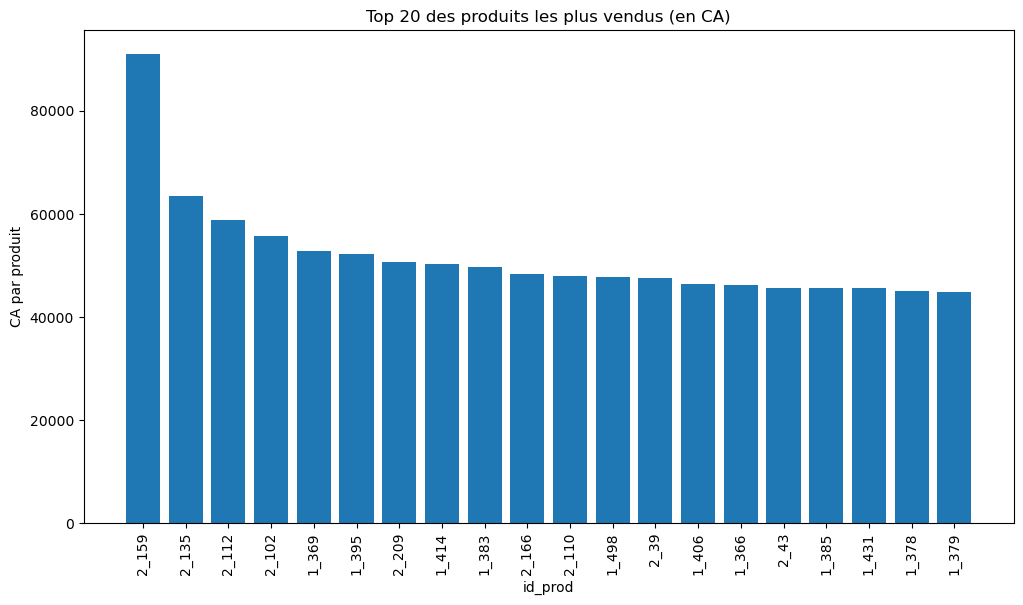

In [32]:
#Produits les plus vendus en CA
top_produits_ca = df_merge_btoc.groupby('id_prod')['price'].sum().reset_index().sort_values('price',ascending=False).head(20)
plt.figure(figsize=(12,6.4))
plt.xlabel('id_prod')
plt.ylabel('CA par produit')
plt.title('Top 20 des produits les plus vendus (en CA)')
plt.xticks(rotation=90)
plt.bar(height=top_produits_ca['price'],x=top_produits_ca['id_prod'])
plt.show()

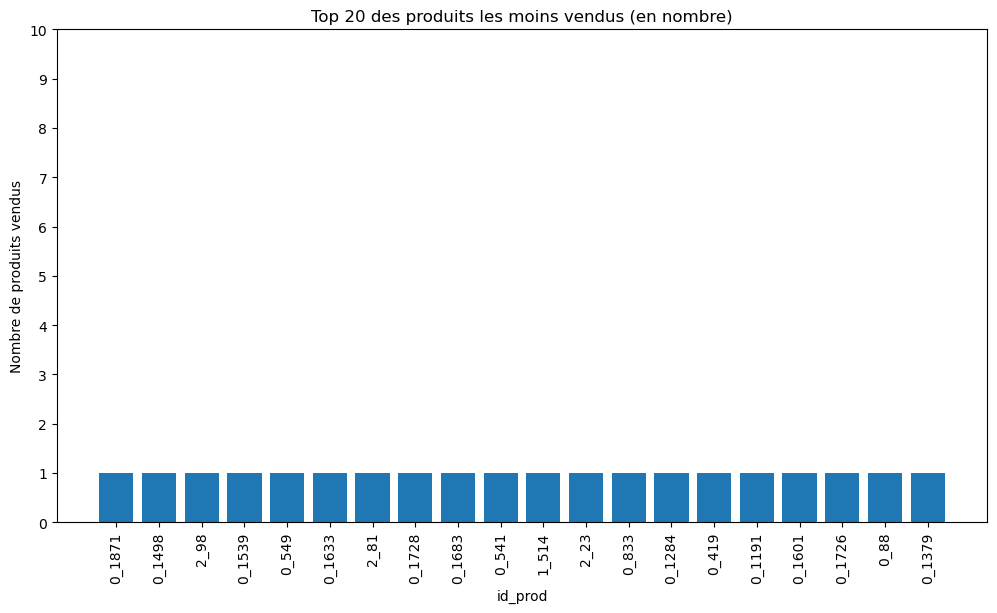

In [33]:
#Produits les moins vendus en quantité
flop_produits = df_merge_btoc['id_prod'].value_counts().reset_index().sort_values('count').head(20)
plt.figure(figsize=(12,6.4))
plt.xlabel('id_prod')
plt.ylabel('Nombre de produits vendus')
plt.title('Top 20 des produits les moins vendus (en nombre)')
plt.xticks(rotation=90)
plt.yticks(range(0,11,1))
plt.ylim(0,10)
plt.bar(height=flop_produits['count'],x=flop_produits['id_prod'])
plt.show()

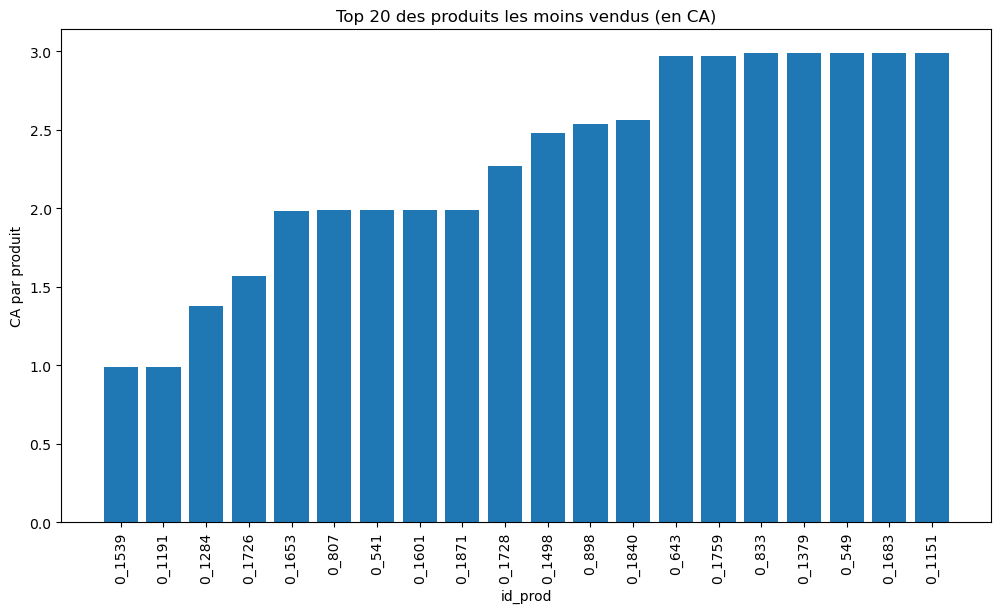

In [34]:
#Produits les moins vendus en CA
flop_produits_ca = df_merge_btoc.groupby('id_prod')['price'].sum().reset_index().sort_values('price',ascending=True).head(20)
plt.figure(figsize=(12,6.4))
plt.xlabel('id_prod')
plt.ylabel('CA par produit')
plt.title('Top 20 des produits les moins vendus (en CA)')
plt.xticks(rotation=90)
plt.bar(height=flop_produits_ca['price'],x=flop_produits_ca['id_prod'])
plt.show()

In [35]:
#Produits invendus
produits_invendus = products.loc[~products['id_prod'].isin(df_merge_btoc['id_prod']),:]
print(f"Il y a {produits_invendus.shape[0]} produit(s) invendu(s).\n\nCi-dessous la liste : \n\n{produits_invendus}")

Il y a 24 produit(s) invendu(s).

Ci-dessous la liste : 

     id_prod   price  categ
184   0_1016   35.06      0
279   0_1780    1.67      0
736   0_1062   20.08      0
793   0_1119    2.99      0
810   0_1014    1.15      0
845      1_0   31.82      1
914    0_695   25.99      0
1030  0_1318   20.92      0
1138  0_1800   22.05      0
1346  0_1645    2.99      0
1357  0_1074    2.44      0
1504   0_322    2.99      0
1529  0_1620    0.80      0
1542  0_1025   24.99      0
1708    2_87  220.99      2
1862   1_394   39.73      1
1945    2_72  141.32      2
2214   0_310    1.94      0
2407  0_1624   24.50      0
2524    2_86  132.36      2
2689   0_299   22.99      0
3030   0_510   23.66      0
3095  0_2308   20.28      0
3150   2_130  142.58      2


In [36]:
#Existe-il des produits vendus inconnus dans la table products ?
produits_vendus_inconnus = df_merge_btoc.loc[~df_merge_btoc['id_prod'].isin(products['id_prod']),:]
print(f"Il y a {produits_vendus_inconnus.shape[0]} produit(s) vendu(s) non présent(s) dans la table products.\n\nCi-dessous la liste : \n\n{produits_vendus_inconnus}")

Il y a 0 produit(s) vendu(s) non présent(s) dans la table products.

Ci-dessous la liste : 

Empty DataFrame
Columns: [id_prod, date, session_id, client_id, price, categ, sex, birth]
Index: []


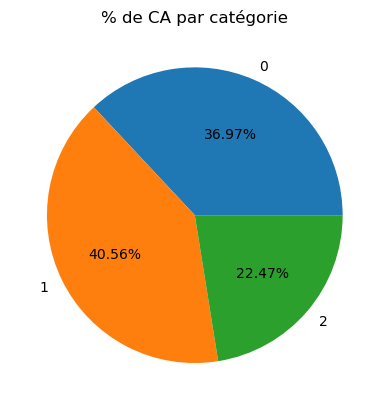

In [37]:
#Répartition du CA par catégorie
CA_par_cat = df_merge_btoc.groupby(df_merge_btoc['categ'])['price'].sum().reset_index()
plt.pie(x=CA_par_cat['price'], labels = CA_par_cat['categ'],autopct ='%.2f%%')
plt.title('% de CA par catégorie')
plt.show()

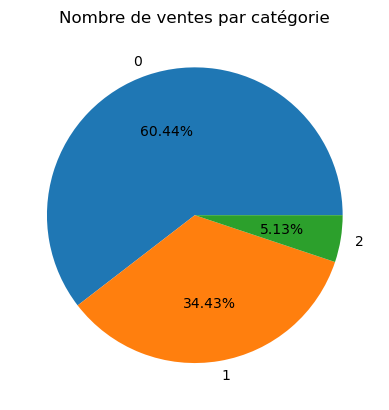

In [38]:
#Répartition du nb de ventes par catégorie
ventes_par_cat = df_merge_btoc.groupby(df_merge_btoc['categ'])['id_prod'].count().reset_index()
plt.pie(x=ventes_par_cat['id_prod'], labels = ventes_par_cat['categ'],autopct ='%.2f%%')
plt.title('Nombre de ventes par catégorie')
plt.show()

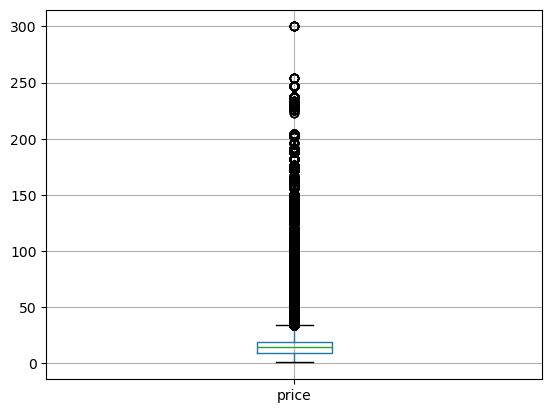

In [39]:
#Distribution des prix des produits
df_merge_btoc.boxplot(column ='price')
plt.show()

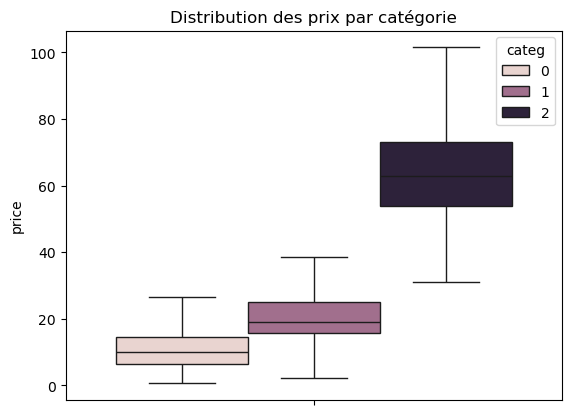

In [40]:
#Distribution des prix par catégorie de produits
sns.boxplot(data = df_merge_btoc, y='price', hue = 'categ',showfliers=False)
plt.title('Distribution des prix par catégorie')
plt.show()

## 3. Analyse des comportements clients

### 3.1 Lien entre genre d'un client et les catégories de livres achetés

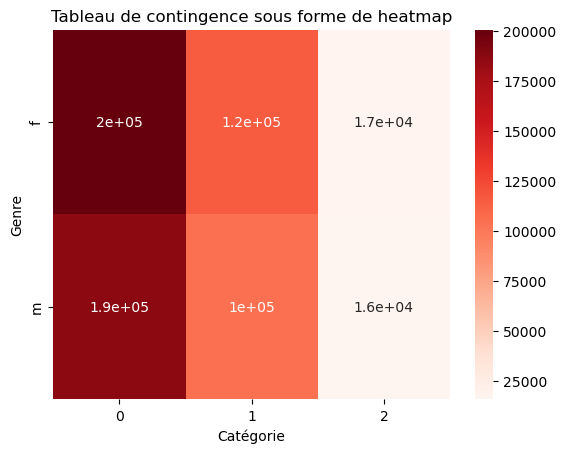

In [41]:
#Etude du lien entre 2 variables qualitatives : genre et catégories
# Créer le tableau de contingence
contingency_table = pd.crosstab(df_merge_btoc['sex'], df_merge_btoc['categ'])

#Visualisation du tableau de contingence sous forme de heatmap
sns.heatmap(contingency_table,annot=True,cmap='Reds')
plt.title("Tableau de contingence sous forme de heatmap")
plt.xlabel('Catégorie')
plt.ylabel('Genre')
plt.show()

In [42]:
# Calculer le test du Chi-2
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

#Hypothèse H0 : les variables sont indépendantes
#Hypothèse H1 : Les variables sont dépendantes
#Seuil choisi 
seuil = 0.05

print(f"Statistique Chi-2: {round(chi2_stat,2)}")
print(f"Valeur p: {p_value}")
if p_value < seuil :
    print("La p-value est inférieure au seuil choisi, l'hypothèse H0 est rejetée et le lien entre genre et catégorie n'est probablement pas lié au hasard.")
else : 
    print("La p-value est supérieure au seuil choisi, l'hypothèse H0 n'est pas rejettée et le lien entre genre et catégorie pourrait être dû au hasard.")


Statistique Chi-2: 22.67
Valeur p: 1.1955928116587024e-05
La p-value est inférieure au seuil choisi, l'hypothèse H0 est rejetée et le lien entre genre et catégorie n'est probablement pas lié au hasard.


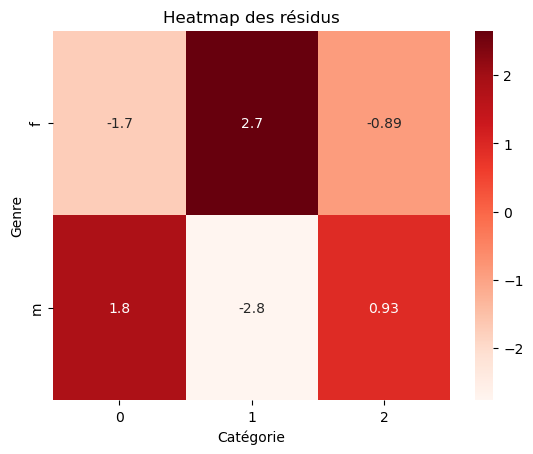

In [43]:
#Pour mieux comprendre ce lien entre les variables, on réaliser une heatmap des résidus
residus = (contingency_table - expected) / np.sqrt(expected)
sns.heatmap(residus,annot=True,cmap='Reds')
plt.title('Heatmap des résidus')
plt.xlabel('Catégorie')
plt.ylabel('Genre')
plt.show()

### 3.2 Lien entre âge des clients et montant total des achats

In [44]:
#Etude du lien entre 2 variables quantitatives : âge et montant total des achats
#Détermination de l'âge
df_merge_btoc['age'] = 2022 - df_merge_btoc['birth']

#table pour étude corrélation
age_montant = df_merge_btoc.groupby(['client_id','age'])['price'].sum().reset_index()
age_montant

C:\Users\agnes\AppData\Local\Temp\ipykernel_37808\4139064828.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merge_btoc['age'] = 2022 - df_merge_btoc['birth']


,client_id,age,price
0,c_1,67,629.02
1,c_10,66,1353.60
2,c_100,30,254.85
3,c_1000,56,2291.88
4,c_1001,40,1823.85
...,...,...,...
8591,c_995,67,189.41
8592,c_996,52,1637.34
8593,c_997,28,1490.01
8594,c_998,21,2822.22


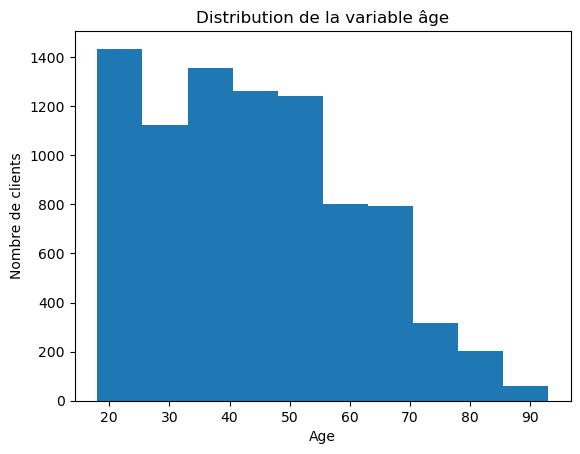

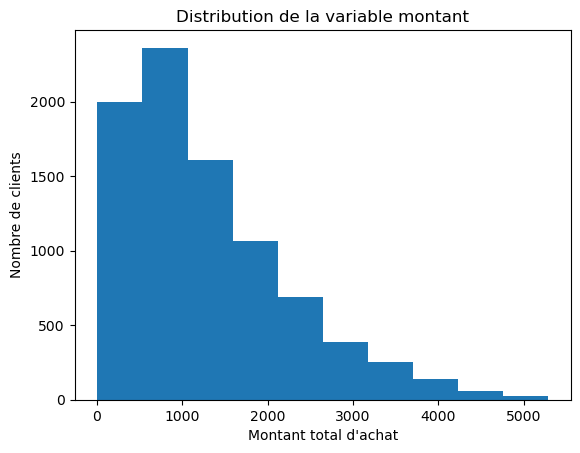

In [45]:
#Etude de la distribution des variables pour choisir le test de corrélation adéquat
plt.title('Distribution de la variable âge')
plt.xlabel('Age')
plt.ylabel('Nombre de clients')
plt.hist(age_montant['age'],bins=10)
plt.show()
plt.title('Distribution de la variable montant')
plt.xlabel("Montant total d'achat")
plt.ylabel('Nombre de clients')
plt.hist(age_montant['price'],bins=10)
plt.show()

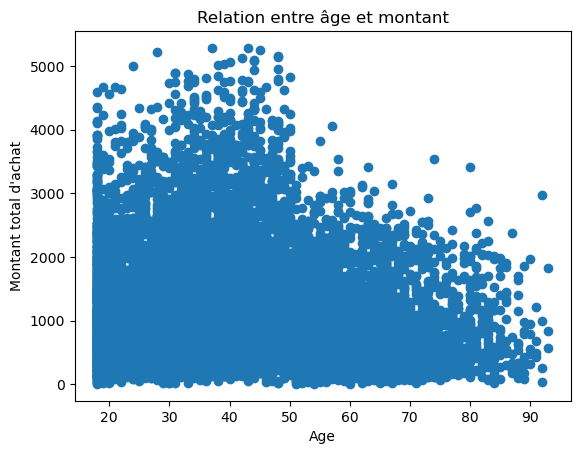

In [46]:
#Visualiation du lien entre âge et montant
plt.scatter(age_montant['age'], age_montant['price'])
plt.title('Relation entre âge et montant')
plt.xlabel('Age')
plt.ylabel("Montant total d'achat")
plt.show()

In [47]:
#Test de Spearman

#Hypothèse H0 : Il n'y a pas de corrélation entre les 2 variables
#Hypothèse H1 : Il y a bien une corrélation entre les 2 variables

#Seuil choisi 
seuil = 0.05

correlation, p_value = spearmanr(age_montant['age'], age_montant['price'])

print(f"Coefficient de corrélation de Spearman : {round(correlation,2)}")
print(f"Valeur p: {p_value}")

Coefficient de corrélation de Spearman : -0.18
Valeur p: 1.0212910436382683e-66


### 3.3 Lien entre âge des clients et fréquence d'achat

In [48]:
#Etude du lien entre 2 variables quantitatives : âge et fréquence d'achat
#Détermination de la fréquence d'achat
df_merge_btoc = df_merge_btoc.sort_values(['client_id','date'])
df_merge_btoc['achat_precedent'] = df_merge_btoc.groupby('client_id')['date'].shift()
df_merge_btoc['frequence'] = (df_merge_btoc['date'] - df_merge_btoc['achat_precedent']).dt.days

#table pour étude corrélation
age_frequence = df_merge_btoc.groupby(['client_id','age'])['frequence'].mean().round(2).reset_index()
age_frequence

,client_id,age,frequence
0,c_1,67,13.57
1,c_10,66,11.54
2,c_100,30,73.86
3,c_1000,56,5.08
4,c_1001,40,6.82
...,...,...,...
8591,c_995,67,45.23
8592,c_996,52,7.19
8593,c_997,28,10.93
8594,c_998,21,12.87


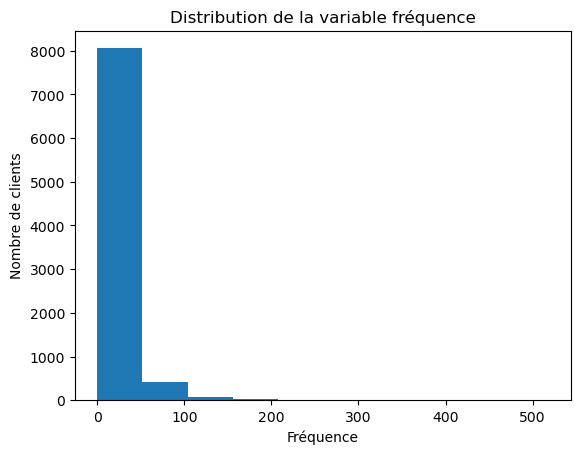

In [49]:
#Etude de la distribution de la fréquence pour choisir le test de corrélation adéquat
plt.title('Distribution de la variable fréquence')
plt.xlabel('Fréquence')
plt.ylabel('Nombre de clients')
plt.hist(age_frequence['frequence'],bins=10)
plt.show()

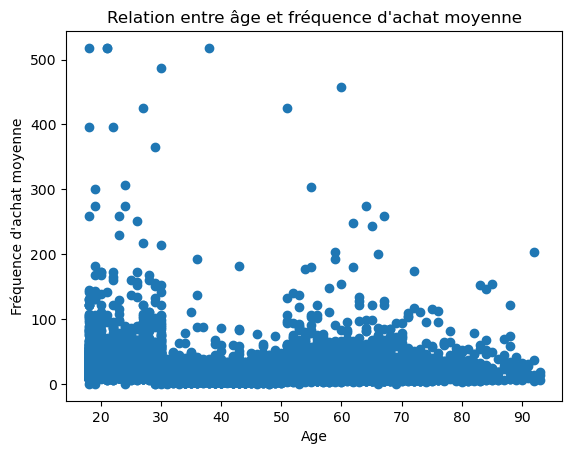

In [50]:
#Visualisation du lien entre âge et fréquence
plt.scatter(age_frequence['age'], age_frequence['frequence'])
plt.title("Relation entre âge et fréquence d'achat moyenne")
plt.xlabel('Age')
plt.ylabel("Fréquence d'achat moyenne")
plt.show()

In [51]:
#Test de Spearman

#Hypothèse H0 : Il n'y a pas de corrélation entre les 2 variables
#Hypothèse H1 : Il y a bien une corrélation entre les 2 variables

#Seuil choisi 
seuil = 0.05

correlation, p_value = spearmanr(age_frequence['age'], age_frequence['frequence'],nan_policy = 'omit')

print(f"Coefficient de corrélation de Spearman : {round(correlation,2)}")
print(f"Valeur p: {p_value}")

Coefficient de corrélation de Spearman : -0.12
Valeur p: 1.3569208150455367e-29


### 3.4 Lien entre âge des clients et taille du panier moyen

In [52]:
#Etude du lien entre 2 variables quantitatives : âge et panier moyen
#table pour étude corrélation
age_panier = df_merge_btoc.groupby(['client_id','age'])['price'].mean().round(2).reset_index()
age_panier

,client_id,age,price
0,c_1,67,14.63
1,c_10,66,23.34
2,c_100,30,31.86
3,c_1000,56,18.19
4,c_1001,40,17.71
...,...,...,...
8591,c_995,67,13.53
8592,c_996,52,17.06
8593,c_997,28,25.25
8594,c_998,21,51.31


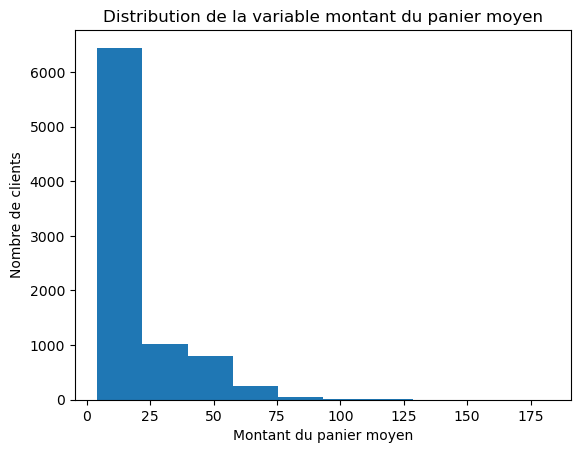

In [53]:
#Etude de la distribution du panier moyen pour choisir le test de corrélation adéquat
plt.title('Distribution de la variable montant du panier moyen')
plt.xlabel('Montant du panier moyen')
plt.ylabel('Nombre de clients')
plt.hist(age_panier['price'],bins=10)
plt.show()

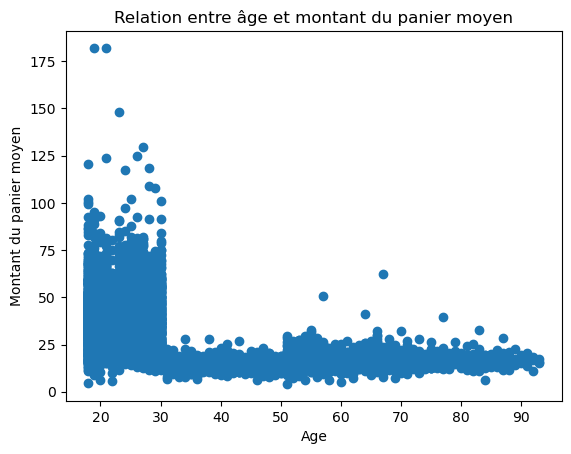

In [54]:
#Visualisation du lien entre âge et panier moyen
plt.scatter(age_panier['age'], age_panier['price'])
plt.title('Relation entre âge et montant du panier moyen')
plt.xlabel('Age')
plt.ylabel("Montant du panier moyen")
plt.show()

In [55]:
#Test de Spearman

#Hypothèse H0 : Il n'y a pas de corrélation entre les 2 variables
#Hypothèse H1 : Il y a bien une corrélation entre les 2 variables

#Seuil choisi 
seuil = 0.05

correlation, p_value = spearmanr(age_panier['age'], age_panier['price'])

print(f"Coefficient de corrélation de Spearman : {round(correlation,2)}")
print(f"Valeur p: {p_value}")

Coefficient de corrélation de Spearman : -0.33
Valeur p: 8.2034511559647e-212


### 3.5 Lien entre âge des clients et catégorie de livres achetées

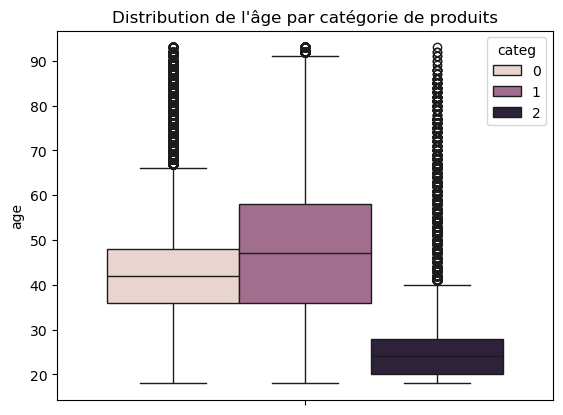

In [56]:
#Etude du lien entre 1 variable quantitative et 1 variable qualitative : âge et catégorie de produits
#Visualisation de l'âge par catégorie de produits
sns.boxplot(data = df_merge_btoc, y='age', hue = 'categ')
plt.title("Distribution de l'âge par catégorie de produits")
plt.show()

In [57]:
#test ANOVA
#Sélection des infos par catégorie
age0 = df_merge_btoc.loc[df_merge_btoc['categ'] == 0,'age']
age1 = df_merge_btoc.loc[df_merge_btoc['categ'] == 1,'age']
age2 = df_merge_btoc.loc[df_merge_btoc['categ'] == 2,'age']

#Hypothèse H0 : les différences entre les médianes ne sont pas statistiquement significatives
#Hypothèse H1 : les différences entre certaines médianes sont statistiquement significatives
#Seuil choisi 
seuil = 0.05

# Calculer le test ANOVA et la valeur p
f_stat, p_value = f_oneway(age0, age1, age2)

print(f"Statistique de test F: {round(f_stat,2)}")
print(f"Valeur p: {p_value}")

if p_value < seuil :
    print("La p-value est inférieure au seuil choisi, l'hypothèse H0 est rejetée et le lien entre âge et catégorie n'est probablement pas lié au hasard.")
else : 
    print("La p-value est supérieure au seuil choisi, l'hypothèse H0 n'est pas rejettée et le lien entre âge et catégorie pourrait être dû au hasard.")

Statistique de test F: 39705.52
Valeur p: 0.0
La p-value est inférieure au seuil choisi, l'hypothèse H0 est rejetée et le lien entre âge et catégorie n'est probablement pas lié au hasard.


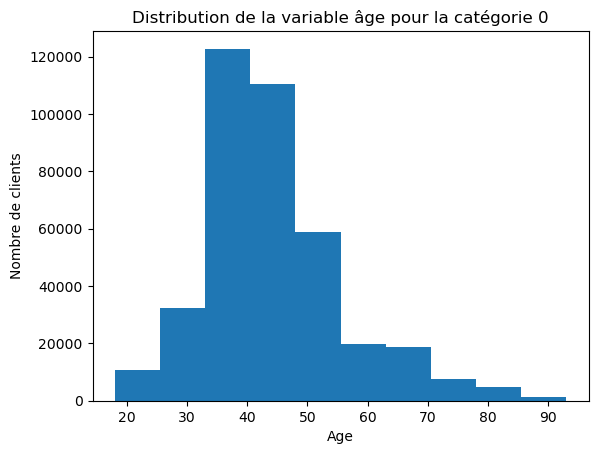

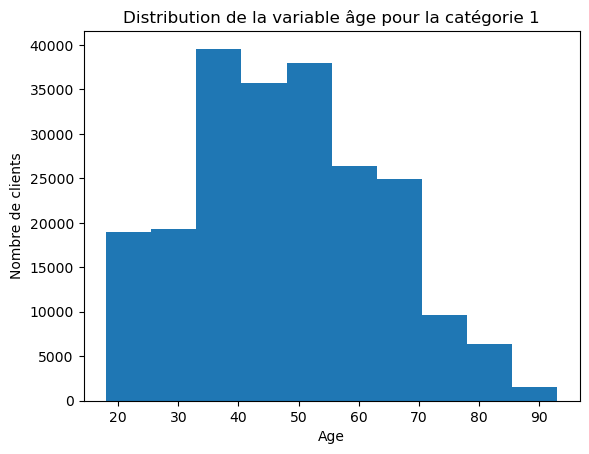

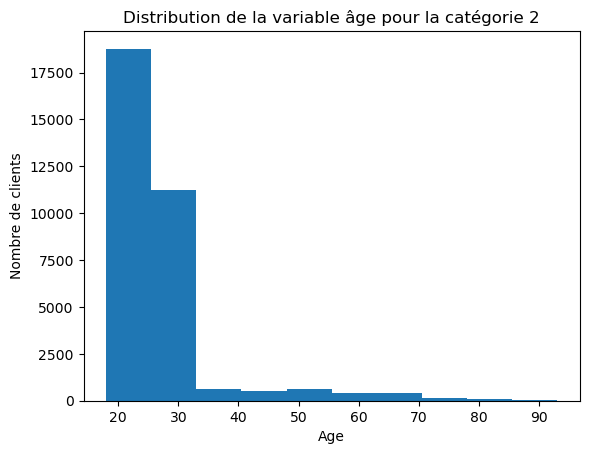

In [58]:
#Visualisation de la distribution de l'âge dans chaque catégorie pour savoir s'il était pertinent d'utiliser le test ANOVA dans ce cas
age0 = df_merge_btoc.loc[df_merge_btoc['categ'] == 0,'age']
age1 = df_merge_btoc.loc[df_merge_btoc['categ'] == 1,'age']
age2 = df_merge_btoc.loc[df_merge_btoc['categ'] == 2,'age']
plt.title('Distribution de la variable âge pour la catégorie 0')
plt.xlabel('Age')
plt.ylabel('Nombre de clients')
plt.hist(age0,bins=10)
plt.show()
plt.title('Distribution de la variable âge pour la catégorie 1')
plt.xlabel('Age')
plt.ylabel('Nombre de clients')
plt.hist(age1,bins=10)
plt.show()
plt.title('Distribution de la variable âge pour la catégorie 2')
plt.xlabel('Age')
plt.ylabel('Nombre de clients')
plt.hist(age2,bins=10)
plt.show()

In [59]:
#Test de Kruskal-Wallis

#Hypothèse H0 : les différences entre les médianes ne sont pas statistiquement significatives
#Hypothèse H1 : les différences entre certaines médianes sont statistiquement significatives
#Seuil choisi 
seuil = 0.05

H, p_value = kruskal(age0,age1,age2)

print(f"Statistique H: {round(H,2)}")
print(f"Valeur p: {p_value}")
if p_value < seuil :
    print("La p-value est inférieure au seuil choisi, l'hypothèse H0 est rejetée et le lien entre âge et catégorie n'est probablement pas lié au hasard.")
else : 
    print("La p-value est supérieure au seuil choisi, l'hypothèse H0 n'est pas rejettée et le lien entre âge et catégorie pourrait être dû au hasard.")


Statistique H: 71359.73
Valeur p: 0.0
La p-value est inférieure au seuil choisi, l'hypothèse H0 est rejetée et le lien entre âge et catégorie n'est probablement pas lié au hasard.
